# 05 - Clustering for Vector Search

---

In the previous notebook, we learned Approximate Nearest Neighbor (ANN).

ANN reduces search time by avoiding comparisons with every vector.

But another question appears.

How can we intelligently divide millions of vectors into smaller groups?

This notebook introduces **Clustering**, the foundation of IVF (Inverted File Index).

##  History

Suppose a vector database contains

1 billion vectors.

Searching every vector is expensive.

Researchers asked:

"What if we group similar vectors together?"

Instead of searching the entire database,

we search only inside one or a few groups.

This idea became Clustering.

Later, IVF used the same concept.

## Think Like a Researcher

Imagine a library.

Instead of placing every book randomly,

we organize them into sections.

- AI
- Finance
- Sports
- History

Now,

if someone asks for an AI book,

we don't search the whole library.

We search only the AI section.

Clustering follows the same idea.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

cluster1 = np.random.randn(30,2)+[2,2]

cluster2 = np.random.randn(30,2)+[8,2]

cluster3 = np.random.randn(30,2)+[5,8]

vectors = np.vstack([
    cluster1,
    cluster2,
    cluster3
])

vectors.shape

(90, 2)

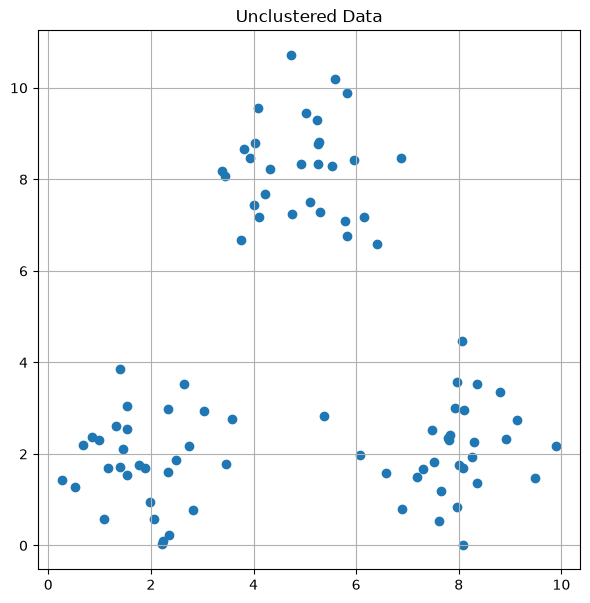

In [2]:
plt.figure(figsize=(7,7))

plt.scatter(
    vectors[:,0],
    vectors[:,1]
)

plt.title("Unclustered Data")

plt.grid()

plt.show()

## Observation

Although all points are mixed together,

our eyes naturally notice

three groups.

Computers need an algorithm to discover these groups automatically.

One of the most popular algorithms is **K-Means**.

## What is Clustering?

Clustering is an **unsupervised learning** technique.

Its goal is to group similar data points together.

Points inside one cluster are

- similar to each other

and

- different from points in other clusters.

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(vectors)

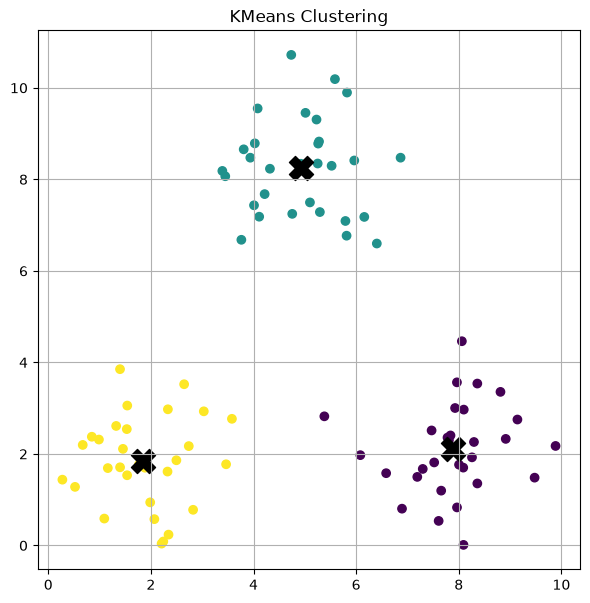

In [4]:
plt.figure(figsize=(7,7))

plt.scatter(
    vectors[:,0],
    vectors[:,1],
    c=labels
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker="X",
    s=300,
    color="black"
)

plt.title("KMeans Clustering")

plt.grid()

plt.show()

## Observation

Each color represents one cluster.

The black X marks are called

**Centroids**.

A centroid represents the center of a cluster.

##  Centroid

A centroid is the average location of all vectors inside a cluster.

When a new vector arrives,

we first find the nearest centroid.

Then we search only inside that cluster.

This idea later becomes IVF.

In [5]:
kmeans.cluster_centers_

array([[7.89407899, 2.09855416],
       [4.92909716, 8.25473135],
       [1.85584744, 1.8348432 ]])

In [6]:
query = np.array([[4.8,7.6]])

cluster = kmeans.predict(query)

cluster

array([1], dtype=int32)

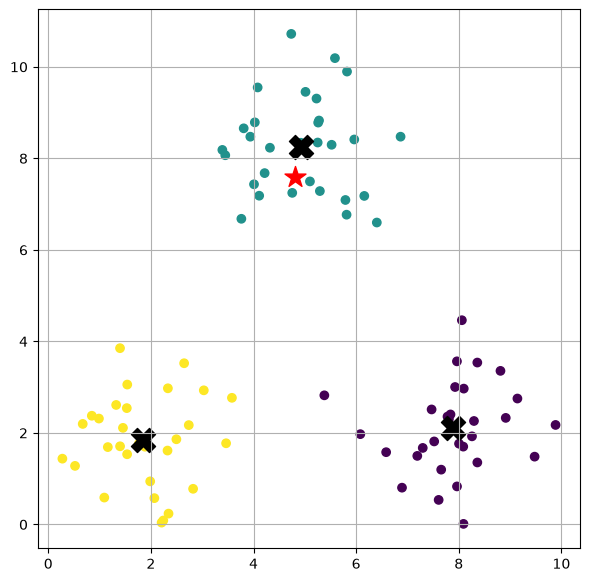

In [7]:
plt.figure(figsize=(7,7))

plt.scatter(
    vectors[:,0],
    vectors[:,1],
    c=labels
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker="X",
    s=300,
    color="black"
)

plt.scatter(
    query[:,0],
    query[:,1],
    color="red",
    s=250,
    marker="*"
)

plt.grid()

plt.show()

## Discussion

Notice:

Instead of searching every point,

we first identify the nearest cluster.

Then,

we search only inside that cluster.

This dramatically reduces the search space.

## Choosing K

Question:

How many clusters should we create?

K = 2

↓

Large clusters

K = 20

↓

Very small clusters

Choosing K is an important design decision.

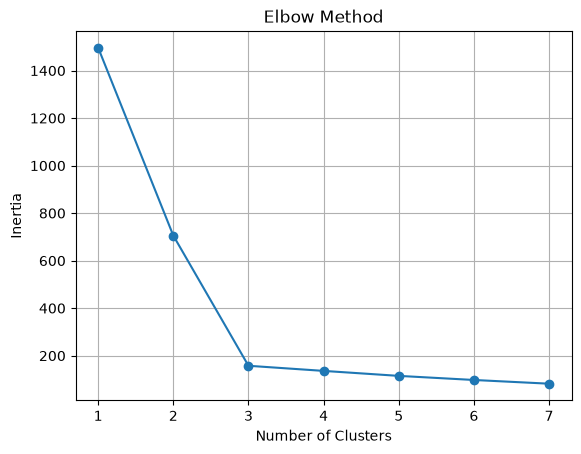

In [ ]:
#Elbow Method
inertia=[]

for k in range(1,8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(vectors)

    inertia.append(model.inertia_)

plt.plot(
    range(1,8),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid()

plt.show()

## Observation

The curve bends like an elbow.

This point often provides a good choice for K.

The Elbow Method is a simple heuristic—it helps guide the choice of K but does not guarantee the best answer for every dataset.

## Applications

Clustering is used in:

- Vector Databases
- Customer Segmentation
- Recommendation Systems
- Image Grouping
- Document Organization
- Data Exploration

##  Limitations

KMeans requires:

- Number of clusters (K)
- Cluster initialization

It also assumes clusters are roughly spherical.

For very complex data,

other clustering algorithms may perform better.

##  Summary

Today I learned:

- What clustering is
- Why clustering is useful
- KMeans
- Centroids
- Choosing K
- Elbow Method
- How clustering reduces search space

##  Think Like a Researcher

Great!

Now we know how to group vectors.

But another question appears.

Suppose we don't want to group vectors.

What is the simplest possible search method?

The answer is

**Flat Index**.

Flat Index compares the query with every stored vector.

Although simple,

it becomes the baseline that all other indexing methods improve upon.